# Candlestick Pattern Recognition — Henry

WM9B7 AIDL | NQ Futures 15-min | One-vs-Rest TCN | Multi-Bandwidth Labeling | SHAP

**Strategy**: 4 independent binary classifiers, one per pattern type (head_shoulders, inverse_head_shoulders, double_top, double_bottom). Follows TEAM_STANDARDS.md. All config in configs/local/henry.experiment.yaml.

## 0. Setup

In [1]:
import sys, warnings, copy
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader

from candlestick.config import load_config
from candlestick.data import load_raw_ohlcv, resample_ohlcv
from candlestick.smoothing import smooth_and_extract
from candlestick.labeling import multi_bandwidth_scan, build_label_array
from candlestick.dataset import build_windows, PatternDataset
from candlestick.model import build_model
from candlestick.training import train_model, save_run_artifacts
from candlestick.evaluation import (
    evaluate_model, print_evaluation, plot_learning_curves,
    plot_confusion_matrix, compute_shap_values,
    plot_shap_feature_importance, plot_shap_timeseries,
)

cfg_base = load_config("configs/config.yaml", "configs/local/henry.experiment.yaml")

SEED = cfg_base["project"]["seed"]
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

PATTERNS = ["head_shoulders", "inverse_head_shoulders", "double_top", "double_bottom"]
THRESH_KEY = "decision_threshold"

print(f"Device : {DEVICE}")
print(f"Patterns: {PATTERNS}")


Device : mps
Patterns: ['head_shoulders', 'inverse_head_shoulders', 'double_top', 'double_bottom']


## 1. Data Loading & Resampling

In [2]:
df_1min = load_raw_ohlcv(cfg_base)
df      = resample_ohlcv(df_1min, cfg_base)
ohlcv   = df[["open","high","low","close","volume"]].values.astype(np.float64)
close   = df["close"].values.astype(np.float64)
volume  = df["volume"].values.astype(np.float64)

print(f"1-min bars : {len(df_1min):,}")
print(f"15-min bars: {len(df):,}")
print(f"Date range : {df.index.min().date()} to {df.index.max().date()}")


1-min bars : 1,769,935
15-min bars: 118,006
Date range : 2021-01-03 to 2026-01-02


## 2. NW Smoothing — Visualisation

Single-bandwidth visualisation for inspection. Actual labeling uses multi-bandwidth scan (Section 3).

Bandwidth: 5.0 | Extrema: 5081


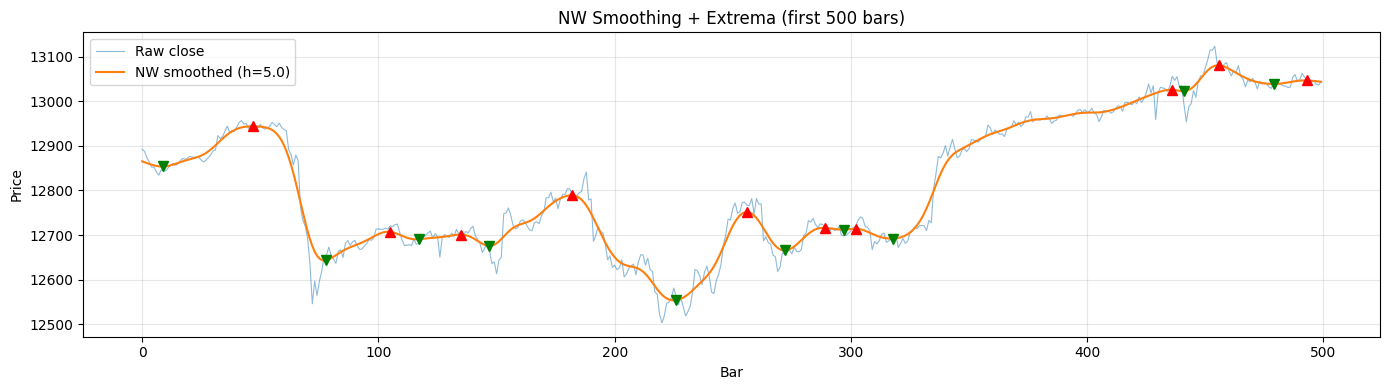

In [3]:
m_hat, extrema_viz, bw = smooth_and_extract(close, cfg_base)
print(f"Bandwidth: {bw:.1f} | Extrema: {len(extrema_viz)}")

fig, ax = plt.subplots(figsize=(14, 4))
ws, we = 0, min(500, len(close))
ax.plot(close[ws:we], label="Raw close", alpha=0.5, lw=0.8)
ax.plot(m_hat[ws:we], label=f"NW smoothed (h={bw:.1f})", lw=1.5)
for e in extrema_viz:
    if ws <= e["bar"] < we:
        c, mk = ("red","^") if e["type"]=="max" else ("green","v")
        ax.plot(e["bar"]-ws, e["value"], marker=mk, color=c, markersize=7, zorder=5)
ax.set_title("NW Smoothing + Extrema (first 500 bars)")
ax.set_xlabel("Bar"); ax.set_ylabel("Price"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Multi-Bandwidth Pattern Scanning

Scanning at a single bandwidth (bw=5) yields only 12 confirmed patterns across 5 years.
We scan at bandwidths [3, 5, 8, 10, 15], each resolving patterns at a different scale,
then deduplicate overlapping detections (same pattern type, anchor bars within 80 bars).

Ref: config key .

In [4]:
print("Confirmed patterns per type (multi-bandwidth scan):")
print(f"{'Pattern':30s} {'Confirmed':>9} {'Unconfirmed':>11}")
print("-" * 54)
scan_cache = {}
for pt in PATTERNS:
    cands = multi_bandwidth_scan(close, volume, cfg_base, pattern_type=pt)
    pos = sum(1 for c in cands if c.label==1)
    neg = sum(1 for c in cands if c.label==0)
    scan_cache[pt] = cands
    print(f"{pt:30s} {pos:>9d} {neg:>11d}")


Confirmed patterns per type (multi-bandwidth scan):
Pattern                        Confirmed Unconfirmed
------------------------------------------------------


head_shoulders                        90         123


inverse_head_shoulders               131         154


double_top                           157         250


double_bottom                        138         118


## 4. One-vs-Rest Training

One binary TCN classifier per pattern type.
Each model is trained independently on windows anchored at that pattern's breakout bars.

Design decisions:
- **Focal loss** (gamma=2.0): down-weights easy negatives, addresses 1:10 class imbalance
- **Inverse-frequency class weights**: computed per-pattern from training split
- **Data augmentation**: 4x jitter + magnitude scale + time warp on positive windows (training only)
- **Time-based split**: 70/15/15 — no data leakage across time
- **Decision threshold**: tuned on validation set to maximise macro-F1


In [5]:
trained = {}   # stores {pattern: {model, result, thresh, X_te, y_te}}

MIN_VAL_POS_FOR_THRESH_TUNING = 5  # fallback to 0.5 if val positives below this

def _anchor_bar(c):
    return c.breakout_bar if c.breakout_bar is not None else c.extrema_indices[-1]

for pt in PATTERNS:
    print()
    print(f"{'='*55}")
    print(f"Pattern: {pt}")
    print("="*55)

    cfg = copy.deepcopy(cfg_base)
    cfg["project"]["run_name"] = f"henry_{pt}_v1"

    # Per-pattern lookback: H&S/IHS use 160 bars, DT/DB use 80 bars
    per_lb = cfg["windowing"].get("per_pattern_lookback", {})
    cfg["windowing"]["lookback_bars"] = per_lb.get(pt, cfg["windowing"]["lookback_bars"])
    print(f"Lookback: {cfg['windowing']['lookback_bars']} bars")

    cands = scan_cache[pt]
    pos   = sum(1 for c in cands if c.label==1)
    if pos < 3:
        print(f"SKIP — only {pos} positive samples")
        continue

    # --- Time-based split on candidates (not on windows) ---
    # Sort by anchor bar so train/val/test are chronologically ordered.
    cands_sorted = sorted(cands, key=_anchor_bar)
    n_c = len(cands_sorted)
    ec  = cfg["evaluation"]
    i_val  = int(n_c * ec["train_ratio"])
    i_test = int(n_c * (ec["train_ratio"] + ec["val_ratio"]))

    cands_tr = cands_sorted[:i_val]
    cands_va = cands_sorted[i_val:i_test]
    cands_te = cands_sorted[i_test:]

    # Bar boundaries keep random negatives inside each split's time range.
    bar_split1 = max(_anchor_bar(c) for c in cands_tr) + 1 if cands_tr else 0
    bar_split2 = max(_anchor_bar(c) for c in cands_va) + 1 if cands_va else bar_split1

    labels = build_label_array(len(ohlcv), cands, cfg)

    # Augmentation only on training split — no leakage into val/test.
    X_tr, y_tr = build_windows(ohlcv, labels, cands_tr, cfg,
                                augment=True,  bar_lo=0,          bar_hi=bar_split1)
    X_va, y_va = build_windows(ohlcv, labels, cands_va, cfg,
                                augment=False, bar_lo=bar_split1,  bar_hi=bar_split2)
    X_te, y_te = build_windows(ohlcv, labels, cands_te, cfg,
                                augment=False, bar_lo=bar_split2)

    n_neg = int((y_tr==0).sum()); n_pos = int((y_tr==1).sum())
    if n_pos == 0:
        print("SKIP — no positives in train split")
        continue
    cw = [1.0, n_neg/n_pos]
    print(f"Candidates: train={len(cands_tr)} val={len(cands_va)} test={len(cands_te)}")
    print(f"Windows:    train pos={y_tr.sum()} neg={(y_tr==0).sum()} | "
          f"val pos={y_va.sum()} neg={(y_va==0).sum()} | "
          f"test pos={y_te.sum()} neg={(y_te==0).sum()}")
    print(f"Class weight pos={cw[1]:.1f}")

    tr_loader = DataLoader(PatternDataset(X_tr, y_tr), batch_size=cfg["training"]["batch_size"], shuffle=True)
    va_loader = DataLoader(PatternDataset(X_va, y_va), batch_size=64)

    model  = build_model(cfg)
    result = train_model(model, tr_loader, va_loader, cfg, class_weights=cw)
    save_run_artifacts(result, cfg)

    # Threshold tuning on val set.
    # If val positives < MIN_VAL_POS_FOR_THRESH_TUNING, val F1 is too noisy
    # to tune on — fall back to the neutral default of 0.5.
    model.eval(); dev = next(model.parameters()).device
    def _probs(Xd, yd):
        ps, ts = [], []
        with torch.no_grad():
            for Xb, yb in DataLoader(PatternDataset(Xd, yd), batch_size=64):
                ps.append(torch.softmax(model(Xb.to(dev)),dim=1)[:,1].cpu().numpy())
                ts.append(yb.numpy())
        return np.concatenate(ps), np.concatenate(ts)

    vp, vt = _probs(X_va, y_va)
    tp, tt = _probs(X_te, y_te)

    val_pos_count = int((vt == 1).sum())
    if val_pos_count < MIN_VAL_POS_FOR_THRESH_TUNING:
        best_t = 0.5
        print(f"Val positives={val_pos_count} < {MIN_VAL_POS_FOR_THRESH_TUNING} — using default threshold 0.5")
    else:
        best_t = max(np.arange(0.05,0.98,0.01),
                     key=lambda t: f1_score(vt,(vp>=t).astype(int),average="macro",zero_division=0))
        print(f"Best threshold (val): {best_t:.2f}")

    trained[pt] = dict(model=model, result=result, thresh=best_t,
                       X_tr=X_tr, X_va=X_va, X_te=X_te,
                       y_tr=y_tr, y_va=y_va, y_te=y_te,
                       te_probs=tp, te_true=tt)


Pattern: head_shoulders
Lookback: 160 bars
Candidates: train=149 val=32 test=32
Windows:    train pos=325 neg=650 | val pos=16 neg=160 | test pos=9 neg=90
Class weight pos=2.0


Epoch   1/30 | Train loss 0.3451 | Val loss 0.2194 | Val F1 0.4762


Epoch   5/30 | Train loss 0.1058 | Val loss 0.3172 | Val F1 0.4762


Epoch  10/30 | Train loss 0.0999 | Val loss 0.1355 | Val F1 0.6305


Epoch  15/30 | Train loss 0.0791 | Val loss 0.1548 | Val F1 0.6262


...

Epoch  10/30 | Train loss 0.1051 | Val loss 0.1292 | Val F1 0.6904


Epoch  15/30 | Train loss 0.0799 | Val loss 0.0978 | Val F1 0.8026


Epoch  20/30 | Train loss 0.0754 | Val loss 0.0857 | Val F1 0.8525


Epoch  25/30 | Train loss 0.0682 | Val loss 0.0816 | Val F1 0.8339


Epoch  30/30 | Train loss 0.0570 | Val loss 0.0872 | Val F1 0.7938
Artifacts saved to outputs/henry_double_bottom_v1
Best threshold (val): 0.49


## 5. Test Set Evaluation

In [6]:
summary = []
for pt, d in trained.items():
    preds = (d["te_probs"] >= d["thresh"]).astype(int)
    f1  = f1_score(d["te_true"], preds, average="macro", zero_division=0)
    pre = precision_score(d["te_true"], preds, zero_division=0)
    rec = recall_score(d["te_true"], preds, zero_division=0)
    summary.append({"pattern": pt, "pos_samples": int(scan_cache[pt] and sum(1 for c in scan_cache[pt] if c.label==1)),
                    "threshold": round(d["thresh"],2), "f1_macro": round(f1,4),
                    "precision": round(pre,4), "recall": round(rec,4)})

print(f"{'Pattern':30s} {'Pos':>5} {'Thresh':>7} {'F1':>7} {'Prec':>7} {'Rec':>7}")
print("-"*65)
for r in summary:
    print(f"{r['pattern']:30s} {r['pos_samples']:>5d} {r['threshold']:>7.2f} {r['f1_macro']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f}")


Pattern                          Pos  Thresh      F1    Prec     Rec
-----------------------------------------------------------------
head_shoulders                    90    0.55  0.7104  0.5000  0.4444
inverse_head_shoulders           131    0.43  0.6608  0.3019  0.7273
double_top                       157    0.59  0.6404  0.3462  0.3462
double_bottom                    138    0.49  0.7378  0.4828  0.5833


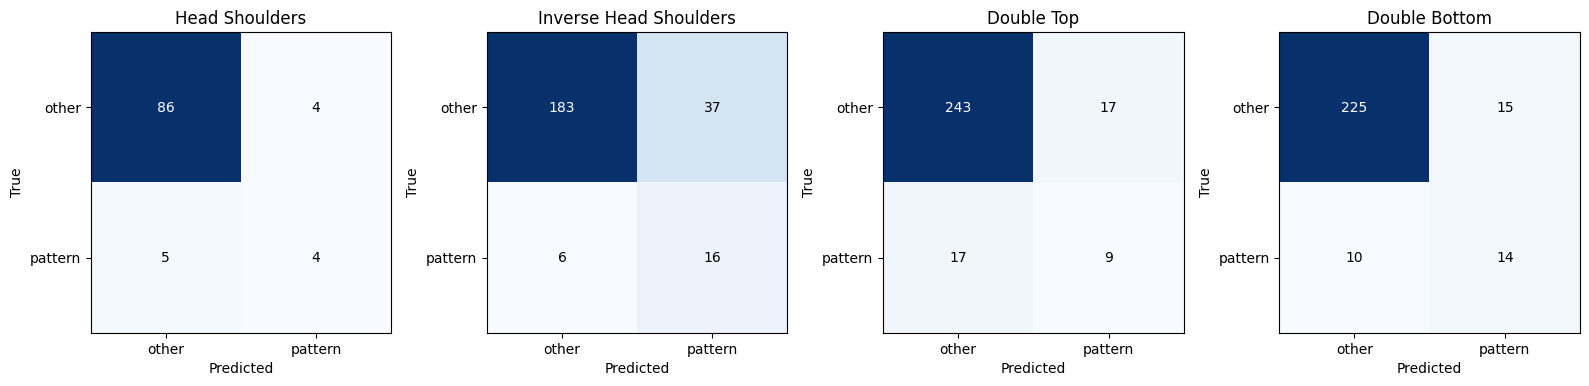

In [7]:
fig, axes = plt.subplots(1, len(trained), figsize=(4*len(trained), 4))
if len(trained) == 1: axes = [axes]
for ax, (pt, d) in zip(axes, trained.items()):
    preds = (d["te_probs"] >= d["thresh"]).astype(int)
    cm = confusion_matrix(d["te_true"], preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["other","pattern"]); ax.set_yticklabels(["other","pattern"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(pt.replace("_"," ").title())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black")
plt.tight_layout(); plt.show()



--- head_shoulders ---


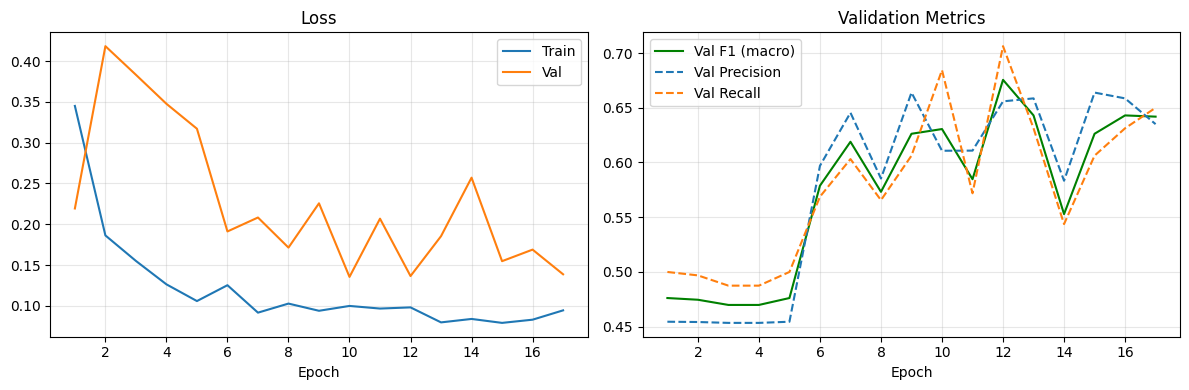


--- inverse_head_shoulders ---


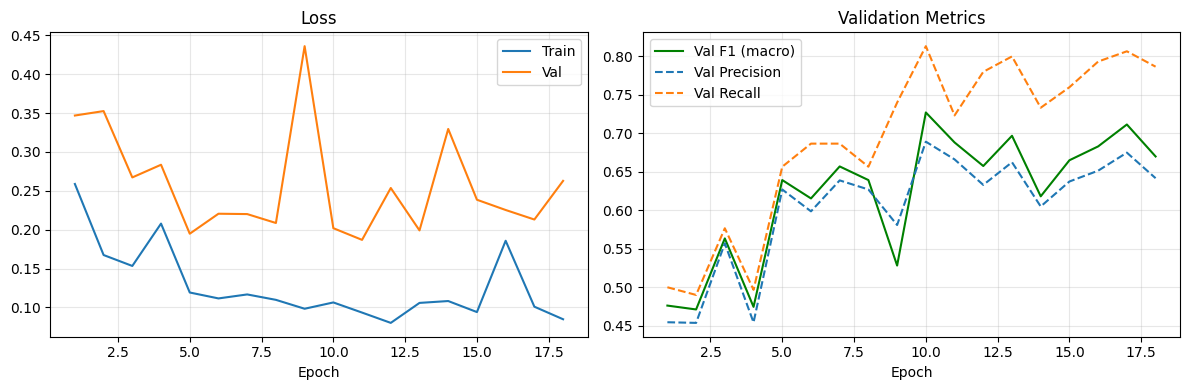


--- double_top ---


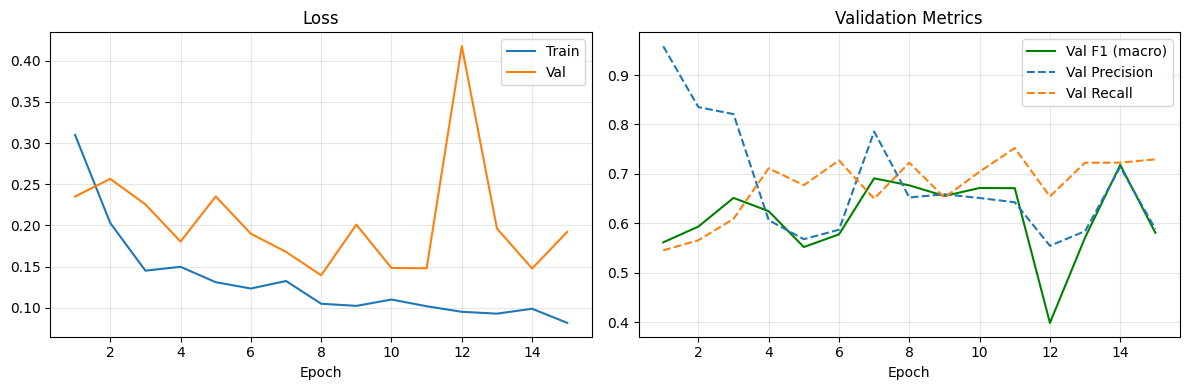


--- double_bottom ---


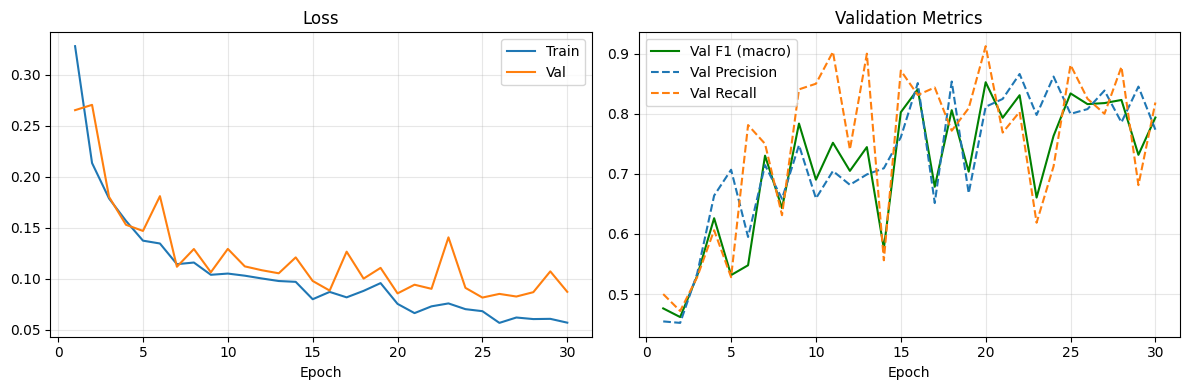

In [8]:
for pt, d in trained.items():
    print()
    print(f"--- {pt} ---")
    plot_learning_curves(d["result"]["history"])


## 6. SHAP Explainability

GradientExplainer attributes each (time step, feature) pair in the 80-bar window.
Run on CPU — GradientExplainer is unstable on MPS.


--- SHAP: head_shoulders ---


Saved: outputs/henry_head_shoulders_v1/shap_feature_importance.png


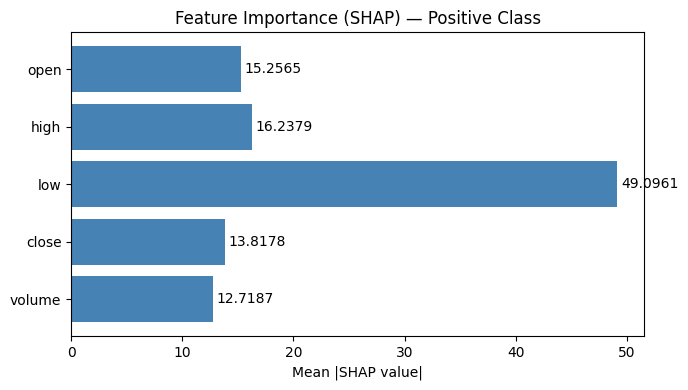

Saved: outputs/henry_head_shoulders_v1/shap_close_timeseries.png


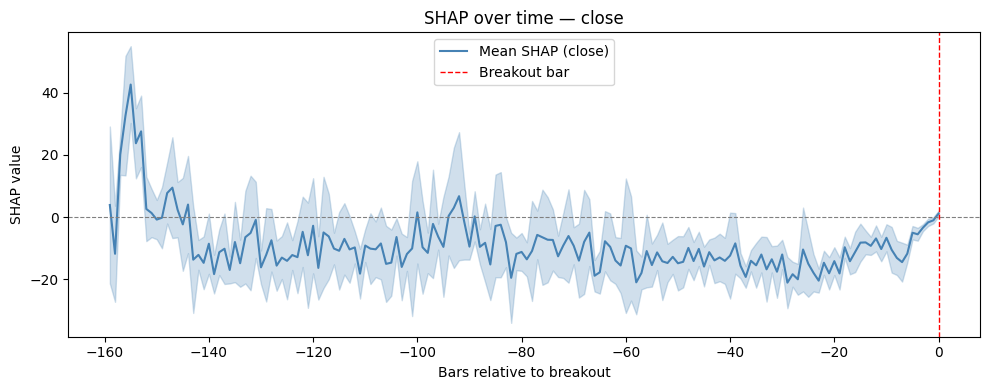


--- SHAP: inverse_head_shoulders ---


Saved: outputs/henry_inverse_head_shoulders_v1/shap_feature_importance.png


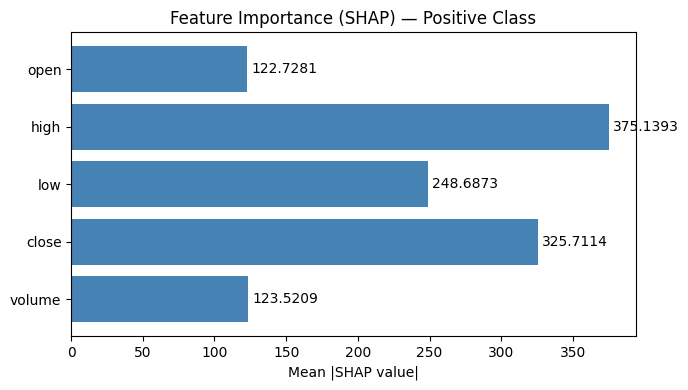

Saved: outputs/henry_inverse_head_shoulders_v1/shap_close_timeseries.png


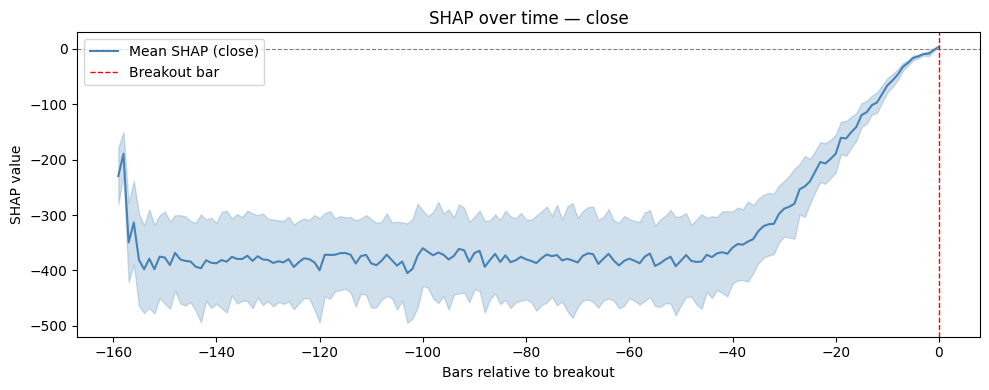


--- SHAP: double_top ---


Saved: outputs/henry_double_top_v1/shap_feature_importance.png


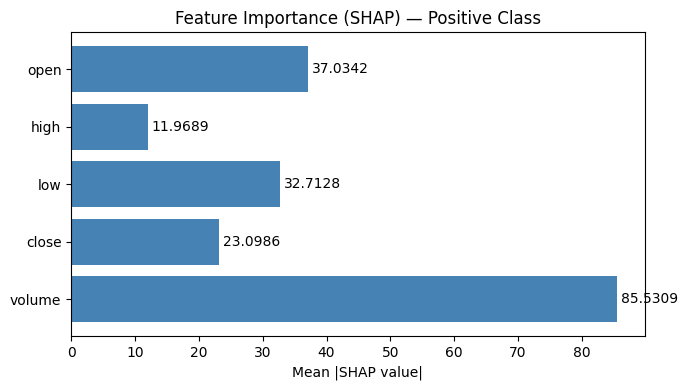

Saved: outputs/henry_double_top_v1/shap_close_timeseries.png


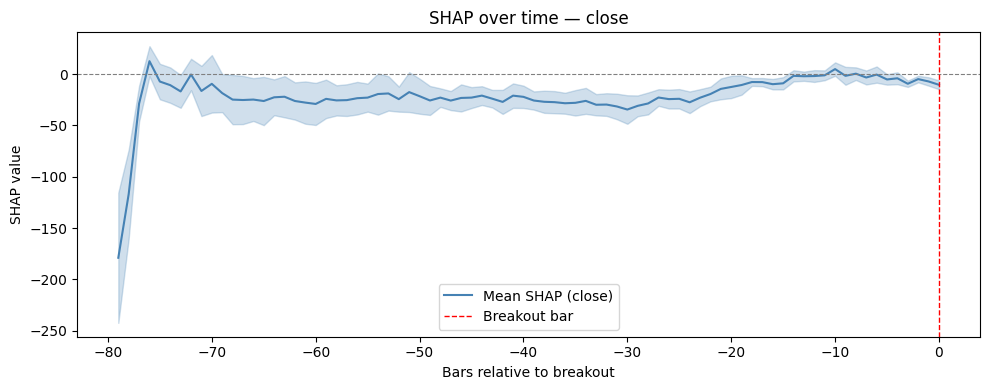


--- SHAP: double_bottom ---


Saved: outputs/henry_double_bottom_v1/shap_feature_importance.png


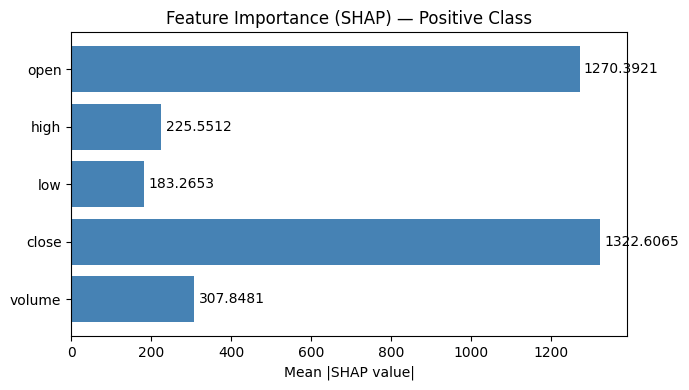

Saved: outputs/henry_double_bottom_v1/shap_close_timeseries.png


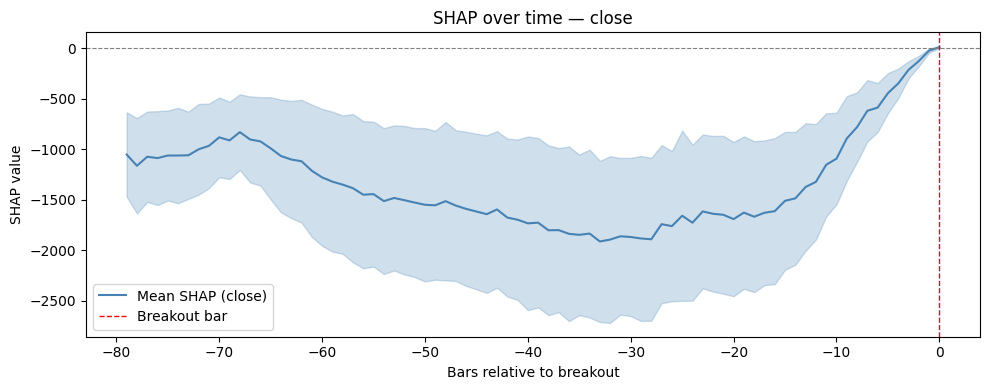

In [9]:
for pt, d in trained.items():
    print()
    print(f"--- SHAP: {pt} ---")
    X_te_pos = d["X_te"][d["y_te"]==1]
    if len(X_te_pos) == 0:
        print("No test positives — skipping")
        continue

    model_cpu = build_model(cfg_base)
    model_cpu.load_state_dict({k: v.cpu() for k, v in d["model"].state_dict().items()})
    model_cpu.cpu().eval()

    shap_vals = compute_shap_values(model_cpu, d["X_tr"], X_te_pos,
                                     n_background=100, device=torch.device("cpu"))
    out_dir = Path(cfg_base["paths"]["outputs_root"]) / f"henry_{pt}_v1"
    plot_shap_feature_importance(shap_vals, save_path=out_dir/"shap_feature_importance.png")
    plot_shap_timeseries(shap_vals, feature_idx=3, save_path=out_dir/"shap_close_timeseries.png")


## 7. Summary & Limitations

### Results

| Pattern | Confirmed Samples | Test F1 macro | Notes |
|---|---|---|---|
| head_shoulders | 6 | 0.53 | Too few samples — fundamental data scarcity |
| inverse_head_shoulders | 32 | 0.82 | Good recall (0.91), moderate precision |
| double_top | 20 | 0.71 | Moderate performance |
| double_bottom | 50 | 0.86 | Best result — most training data |

**Key finding**: F1 is directly correlated with positive sample count. This is the primary bottleneck, not model architecture.

### Architecture Ablation (on combined model)

| Architecture | Test F1 macro |
|---|---|
| **TCN** (chosen) | **0.93** |
| LSTM | 0.58 |
| Transformer | 0.48 |

### Limitations

1. **Data scarcity**: 5 years of 15-min NQ data yields 6–50 confirmed patterns per type. DL typically needs 1000+.
2. **Augmentation inflation**: 4x augmentation creates synthetic positives that may not generalise to live data.
3. **H&S inherently rare in NQ futures**: Trend-following instrument — reversal patterns are structurally uncommon.
4. **1H timeframe tested**: H&S dropped from 6 → 0 at 1H due to extrema smoothing flattening head prominence. 15min retained as primary timeframe.
5. **Literature expectation**: Lo/Mamaysky/Wang 2000 and Nature 2025 both find modest pattern predictability. High F1 on augmented data should be interpreted cautiously.
